In [3]:
import gensim.downloader as api
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.spatial.distance import cosine, euclidean
import nltk
from nltk.corpus import wordnet

nltk.download('wordnet')
model = api.load("glove-wiki-gigaword-100")
print("Vocabulary size:", len(model))

def get_embedding(word):
    word = word.lower()
    
    if word in model:
        return model[word]
    
    # Try synonyms
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            if lemma.name() in model:
                print(f"OOV word approximated using synonym: {lemma.name()}")
                return model[lemma.name()]
    
    print(f"Word '{word}' not found in vocabulary.")
    return None

def compare_words(word1, word2):
    vec1 = get_embedding(word1)
    vec2 = get_embedding(word2)
    
    if vec1 is None or vec2 is None:
        return
    
    print(f"Embedding for {word1} (first 10 values):\n", vec1[:10])
    print()
    print(f"Embedding for {word2} (first 10 values):\n", vec2[:10])

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\James\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Vocabulary size: 400000


In [4]:
while True:
    word1 = input()
    if word1 == "exit":
        break;
    word2 = input()
    if word2 == "exit":
        break;
    compare_words(word1, word2)

 exit


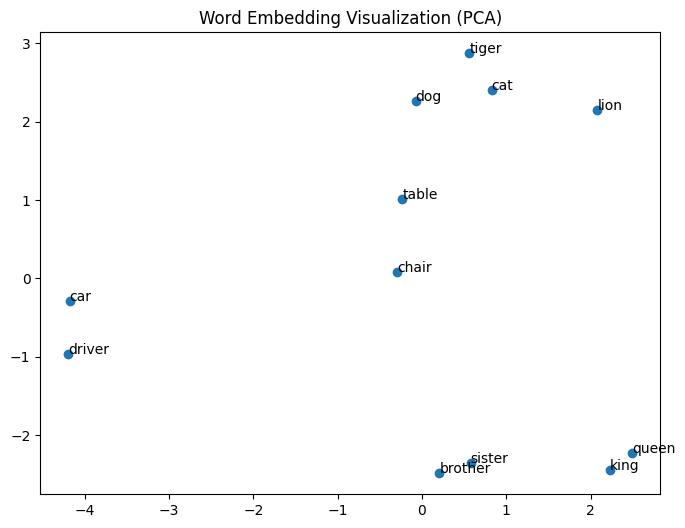

Enter word pairs (format: word1 word2)
Type 'go' to process the batch or 'exit' to quit.


Input:  cow person


Added pair: cow, person


Input:  cow dog


Added pair: cow, dog


...

Added pair: man, waiter


Input:  go



Processing batch...

cow vs person -> cosine similarity: 0.2870
cow vs dog -> cosine similarity: 0.6219
cow vs bison -> cosine similarity: 0.4650
man vs waiter -> cosine similarity: 0.3648

Batch complete.



Input:  exit


Exiting.


In [6]:
def cosine_similarity(vec1, vec2):
    return 1 - cosine(vec1, vec2)
    
def batch_similarity(word_pairs):
    results = []
    
    for w1, w2 in word_pairs:
        vec1 = get_embedding(w1)
        vec2 = get_embedding(w2)
        
        if vec1 is not None and vec2 is not None:
            sim = cosine_similarity(vec1, vec2)
            results.append((w1, w2, sim))
    
    return results

def visualize_words(words):

    vectors = []
    labels = []

    for word in words:
        if word in model:
            vectors.append(model[word])
            labels.append(word)

    vectors = np.array(vectors)

    pca = PCA(n_components=2)
    reduced = pca.fit_transform(vectors)

    plt.figure(figsize=(8,6))
    plt.scatter(reduced[:,0], reduced[:,1])

    for i, word in enumerate(labels):
        plt.annotate(word, (reduced[i,0], reduced[i,1]))

    plt.title("Word Embedding Visualization (PCA)")
    plt.show()


words = ["cat","dog","lion","tiger","car","table","chair","king", "queen","brother","sister","driver"]
visualize_words(words)

def interactive_batch_similarity():

    pairs = []

    print("Enter word pairs (format: word1 word2)")
    print("Type 'go' to process the batch or 'exit' to quit.")

    while True:
        user_input = input("Input: ").strip().lower()

        if user_input == "exit":
            print("Exiting.")
            break

        if user_input == "go":
            if len(pairs) == 0:
                print("No word pairs entered.")
                continue

            print("\nProcessing batch...\n")
            results = batch_similarity(pairs)

            for w1, w2, sim in results:
                print(f"{w1} vs {w2} -> cosine similarity: {sim:.4f}")

            print("\nBatch complete.\n")
            pairs = []  # reset batch
            continue

        # Parse word pair
        words = user_input.split()

        if len(words) != 2:
            print("Please enter exactly two words.")
            continue

        pairs.append((words[0], words[1]))
        print(f"Added pair: {words[0]}, {words[1]}")

interactive_batch_similarity()

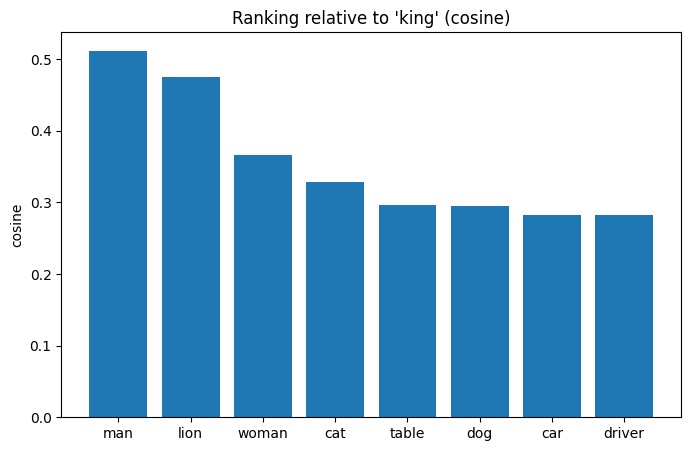

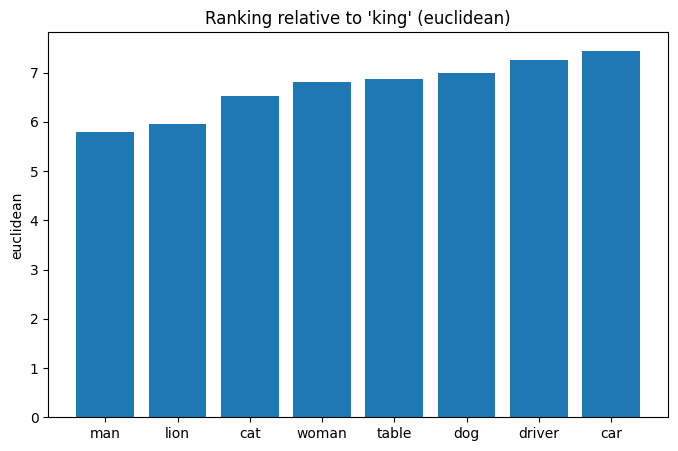

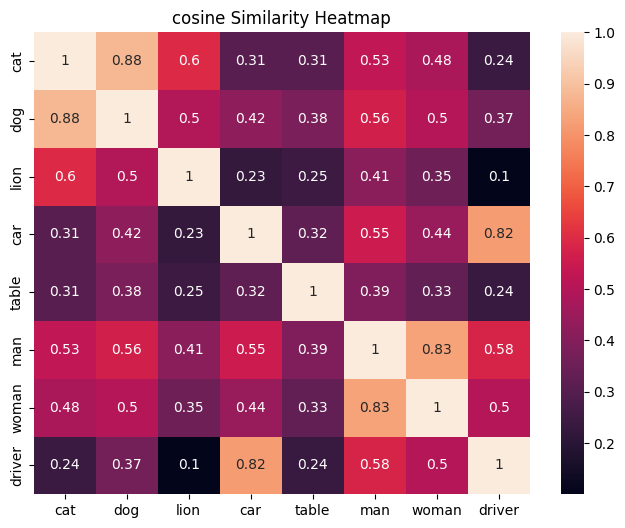

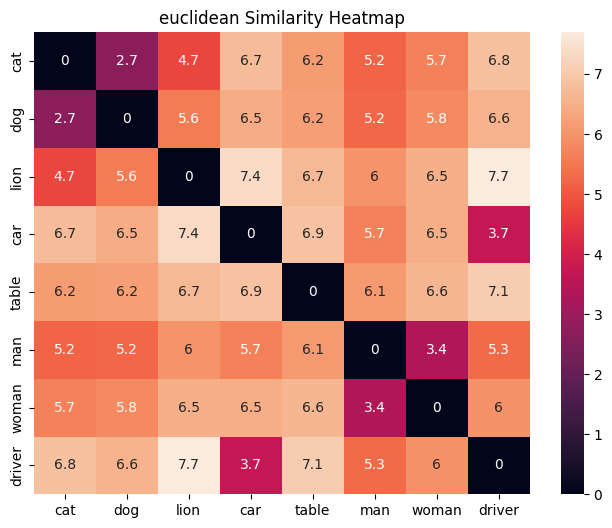

In [10]:
def compute_similarity(word1, word2, metric="cosine"):

    vec1 = get_embedding(word1)
    vec2 = get_embedding(word2)

    if vec1 is None or vec2 is None:
        return None

    if metric == "cosine":
        return cosine_similarity(vec1, vec2)

    elif metric == "euclidean":
        return euclidean(vec1, vec2)

    else:
        raise ValueError("Metric must be 'cosine' or 'euclidean'")

def rank_words(base_word, candidates, metric="cosine"):

    scores = []

    for word in candidates:
        score = compute_similarity(base_word, word, metric)
        if score is not None:
            scores.append((word, score))

    scores.sort(key=lambda x: x[1], reverse=(metric=="cosine"))

    return scores

def plot_ranking(base_word, candidates, metric="cosine"):

    rankings = rank_words(base_word, candidates, metric)

    words = [w for w,_ in rankings]
    scores = [s for _,s in rankings]

    plt.figure(figsize=(8,5))
    plt.bar(words, scores)
    plt.title(f"Ranking relative to '{base_word}' ({metric})")
    plt.ylabel(metric)
    plt.show()

def similarity_heatmap(words, metric="cosine"):

    matrix = np.zeros((len(words), len(words)))

    for i,w1 in enumerate(words):
        for j,w2 in enumerate(words):
            val = compute_similarity(w1, w2, metric)
            if val is not None:
                matrix[i][j] = val

    plt.figure(figsize=(8,6))
    sns.heatmap(matrix, xticklabels=words, yticklabels=words, annot=True)
    plt.title(f"{metric} Similarity Heatmap")
    plt.show()

words = ["cat","dog","lion","car","table","man","woman","driver"]

plot_ranking("king",words,"cosine")
plot_ranking("king",words,"euclidean")

similarity_heatmap(words,"cosine")
similarity_heatmap(words,"euclidean")